In [ ]:
# ============================================================
# IMPORTACIONES
# ============================================================

import os
import glob
import json
import random
import time
import copy
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchinfo import summary
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

from sklearn.metrics import (confusion_matrix, roc_curve, auc, roc_auc_score)

In [ ]:
# ============================================================
# CONFIGURACIÓN DE PYTORCH, GPU Y RUTAS DEL PROYECTO
# ============================================================

SEED_GLOBAL = 42
SEMILLA = SEED_GLOBAL

def fijar_semillas(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

fijar_semillas(SEED_GLOBAL)

print("PyTorch version:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU detectada:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    print("PyTorch NO detectó GPU. El notebook correrá en CPU.")
    device = torch.device("cpu")

print("Dispositivo usado:", device)

# ============================================================
# RUTAS
# ============================================================

RUTA_PROYECTO = Path(".")

directorio_base = RUTA_PROYECTO / "dataset"
directorio_cover = directorio_base / "cover"
directorio_stego_7 = directorio_base / "stego_7"
directorio_stego_15 = directorio_base / "stego_15"

SPLIT_DIR = RUTA_PROYECTO / "splits"
TRAIN_SPLIT_PATH = SPLIT_DIR / "train_base_names.txt"
VAL_SPLIT_PATH = SPLIT_DIR / "val_base_names.txt"
TEST_SPLIT_PATH = SPLIT_DIR / "test_base_names.txt"

METADATA_PATH = RUTA_PROYECTO / "dataset_metadata_pytorch.json"

EXTENSIONES_IMG = ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.pgm", "*.tif", "*.tiff"]

def contar_imagenes(carpeta):
    carpeta = Path(carpeta)
    total = 0
    for ext in EXTENSIONES_IMG:
        total += len(list(carpeta.glob(ext)))
    return total


def leer_lista(path):
    path = Path(path)
    return [
        line.strip()
        for line in path.read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]


carpetas_requeridas = [
    directorio_base,
    directorio_cover,
    directorio_stego_7,
    directorio_stego_15,
    SPLIT_DIR
]

for carpeta in carpetas_requeridas:
    if not carpeta.is_dir():
        raise FileNotFoundError(
            f"No se encontró la carpeta: {carpeta}\n"
            "Ejecuta primero el notebook preparar_dataset.ipynb."
        )

archivos_requeridos = [
    TRAIN_SPLIT_PATH,
    VAL_SPLIT_PATH,
    TEST_SPLIT_PATH
]

for archivo in archivos_requeridos:
    if not archivo.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo de split: {archivo}\n"
            "Ejecuta primero el notebook preparar_dataset.ipynb."
        )

print("\nDataset preparado encontrado:")
print(f"directorio_base: {directorio_base}")
print(f"cover:           {contar_imagenes(directorio_cover)} imágenes")
print(f"stego_7:         {contar_imagenes(directorio_stego_7)} imágenes")
print(f"stego_15:        {contar_imagenes(directorio_stego_15)} imágenes")

if METADATA_PATH.exists():
    with open(METADATA_PATH, "r", encoding="utf-8") as f:
        metadata_dataset = json.load(f)

    print("\nMetadata del dataset cargada:")
    print(f"Cantidad procesada: {metadata_dataset.get('cantidad_a_procesar')}")
    print(f"Semilla: {metadata_dataset.get('seed')}")
    print(f"Formato cover: {metadata_dataset.get('cover_format')}")
else:
    print("\nNo se encontró metadata. El entrenamiento puede continuar, pero se recomienda generarla.")

PyTorch version: 2.7.1+cu118
CUDA disponible: True
GPU detectada: NVIDIA GeForce RTX 4090
Dispositivo usado: cuda


FileNotFoundError: No se encontró la carpeta: .\dataset
Revisa RUTA_PROYECTO o la estructura de carpetas.

# Entrenamiento de red neuronal para esteganálisis de imágenes con Hamming Matrix Embedding

Este notebook entrena y evalúa una red neuronal residual para clasificar imágenes como `cover` o `stego`.

El dataset no se genera en este notebook. Las imágenes ya fueron preparadas previamente en `preparar_dataset.ipynb`, donde se descargó BOSSBase, se aplicó Matrix Embedding con códigos de Hamming y se crearon las particiones train, validation y test sin data leakage.

En este notebook solo se realiza:

- carga del dataset preparado;
- construcción de DataLoaders;
- definición de la arquitectura;
- entrenamiento;
- diagnóstico de sobreajuste;
- evaluación final en test.

# **Fase 3: Entrenamiento del Modelo de esteganálisis**

## **3.1. Construcción del Pipeline de Datos y Partición**

Para la fase de esteganálisis se utiliza PyTorch mediante un `Dataset` personalizado y objetos `DataLoader`. Las imágenes se leen directamente desde las carpetas `cover`, `stego_7` y `stego_15`, evitando depender de una carga completa del dataset en memoria.

El `DatasetEstego` carga cada imagen en escala de grises, la convierte a tensor con formato `(canales, alto, ancho)` y asigna una etiqueta binaria: `0` para imágenes de cobertura y `1` para imágenes stego. En esta versión, las imágenes se mantienen en escala `0-255` antes de entrar a la red, ya que la primera capa de la arquitectura corresponde a un filtro de alto paso fijo diseñado para operar sobre los residuos espaciales de la imagen.

Para evitar *data leakage*, la partición no se realiza a nivel de archivo individual, sino a nivel de imagen base. Primero se identifican los nombres comunes entre `cover` y la clase stego correspondiente. Luego, esos identificadores se dividen en entrenamiento, validación y test. De esta forma, una imagen limpia y su versión esteganográfica siempre quedan en el mismo subconjunto, evitando que el modelo vea durante entrenamiento una variante de una imagen que luego aparece en validación o test.

La partición actual es:

- 60% para entrenamiento.
- 25% para validación.
- 15% para test.

El conjunto de validación se utiliza durante el entrenamiento para monitorear el desempeño y guardar el mejor checkpoint. El conjunto de test se mantiene completamente separado y solo se evalúa al final, en la sección de métricas de clasificación.

Además, se aplica aumento de datos únicamente en entrenamiento mediante volteos horizontales y verticales. No se usan transformaciones agresivas como rotaciones, zoom, recortes o cambios de color, porque podrían alterar artificialmente la estructura de los LSB o introducir patrones no representativos del problema original.

Como primer paso de la construcción del pipeline, primero se verifica que todas las imágenes se encuentren en el formato adecuado (`.png`). 


In [16]:
# ============================================================
# VERIFICACIÓN / CONVERSIÓN OPCIONAL DE COVER A PNG
# ============================================================

print("--- Verificando formato del corpus cover ---")

rutas_png = glob.glob(os.path.join(directorio_cover, "*.png"))
rutas_pgm = glob.glob(os.path.join(directorio_cover, "*.pgm"))

print(f"Imágenes PNG encontradas en cover: {len(rutas_png)}")
print(f"Imágenes PGM encontradas en cover: {len(rutas_pgm)}")

# Keras ya no se usa, pero para mantener compatibilidad con el resto del análisis
# conviene tener PNG disponibles. No se borran los PGM originales.
if len(rutas_png) == 0 and len(rutas_pgm) > 0:
    print("No se encontraron PNG en cover. Convirtiendo PGM a PNG...")

    for ruta in rutas_pgm:
        img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            nueva_ruta = os.path.splitext(ruta)[0] + ".png"
            cv2.imwrite(nueva_ruta, img)

    rutas_png = glob.glob(os.path.join(directorio_cover, "*.png"))
    print(f"Conversión finalizada. PNG disponibles en cover: {len(rutas_png)}")
else:
    print("No es necesario convertir. El corpus cover ya tiene imágenes PNG o PyTorch leerá PGM directamente.")


--- Verificando formato del corpus cover ---
Imágenes PNG encontradas en cover: 1000
Imágenes PGM encontradas en cover: 0
No es necesario convertir. El corpus cover ya tiene imágenes PNG o PyTorch leerá PGM directamente.


In [ ]:
# ============================================================
# PARÁMETROS DE ENTRADA Y LECTURA DE SPLITS
# ============================================================

print("--- 1. Definición de parámetros dinámicos ---")

lista_imagenes = []
for ext in EXTENSIONES_IMG:
    lista_imagenes.extend(list(directorio_cover.glob(ext)))

lista_imagenes = sorted(lista_imagenes)

if lista_imagenes:
    imagen_muestra = cv2.imread(str(lista_imagenes[0]), cv2.IMREAD_GRAYSCALE)
    if imagen_muestra is None:
        raise ValueError(f"No se pudo leer la imagen de muestra: {lista_imagenes[0]}")
    ALTO_IMG, ANCHO_IMG = imagen_muestra.shape
else:
    raise ValueError("No se encontraron imágenes en dataset/cover.")

BATCH_SIZE = 32
NUM_WORKERS = 0
PIN_MEMORY = (device.type == "cuda")

stems_train = leer_lista(TRAIN_SPLIT_PATH)
stems_val = leer_lista(VAL_SPLIT_PATH)
stems_test = leer_lista(TEST_SPLIT_PATH)

print(f"Dataset usado: {directorio_base}")
print(f"Dimensiones de entrada configuradas a: {ALTO_IMG}x{ANCHO_IMG}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train base images: {len(stems_train)}")
print(f"Val base images:   {len(stems_val)}")
print(f"Test base images:  {len(stems_test)}")
print(f"Pin memory: {PIN_MEMORY}")

--- 1. Definición de Parámetros Dinámicos ---
Dataset usado: .\dataset
Dimensiones de entrada configuradas a: 512x512
Batch size: 32
Split por imagen base: train=60%, val=25%, test=15%
Pin memory: True


In [ ]:
# ============================================================
# DATASET Y DATALOADERS DESDE SPLITS YA PREPARADOS
# ============================================================

print("\n--- 2. Construcción de DataLoaders desde splits guardados ---")

class DatasetEstego(Dataset):
    def __init__(self, rutas, etiquetas, alto, ancho, augment=False):
        self.rutas = list(rutas)
        self.etiquetas = list(etiquetas)
        self.alto = alto
        self.ancho = ancho
        self.augment = augment

    def __len__(self):
        return len(self.rutas)

    def __getitem__(self, idx):
        ruta = self.rutas[idx]
        etiqueta = self.etiquetas[idx]

        img = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"No se pudo leer la imagen: {ruta}")

        if img.shape != (self.alto, self.ancho):
            img = cv2.resize(
                img,
                (self.ancho, self.alto),
                interpolation=cv2.INTER_NEAREST
            )

        img = img.astype(np.float32)
        img = torch.from_numpy(img).unsqueeze(0)

        if self.augment:
            if random.random() < 0.5:
                img = torch.flip(img, dims=[2])
            if random.random() < 0.5:
                img = torch.flip(img, dims=[1])

        etiqueta = torch.tensor([float(etiqueta)], dtype=torch.float32)

        return img, etiqueta


def listar_imagenes_clase(directorio_clase):
    directorio_clase = Path(directorio_clase)
    rutas = []

    for ext in EXTENSIONES_IMG:
        rutas.extend(list(directorio_clase.glob(ext)))

    return sorted(rutas)


def listar_imagenes_por_stem(directorio_clase):
    """
    Retorna un diccionario {stem: ruta_imagen}.
    Si existen duplicados con extensiones distintas, prioriza PNG.
    """
    prioridad_extension = {
        ".png": 0,
        ".pgm": 1,
        ".bmp": 2,
        ".tif": 3,
        ".tiff": 4,
        ".jpg": 5,
        ".jpeg": 6,
    }

    por_stem = {}

    for ruta in listar_imagenes_clase(directorio_clase):
        path = Path(ruta)
        stem = path.stem
        ext = path.suffix.lower()

        if stem not in por_stem:
            por_stem[stem] = path
        else:
            ext_actual = por_stem[stem].suffix.lower()
            if prioridad_extension.get(ext, 99) < prioridad_extension.get(ext_actual, 99):
                por_stem[stem] = path

    return por_stem


def construir_dataset_desde_stems(stems, rutas_por_clase, class_names, alto, ancho, augment=False, seed=42):
    rutas = []
    etiquetas = []

    for stem in stems:
        for etiqueta, clase in enumerate(class_names):
            rutas.append(rutas_por_clase[clase][stem])
            etiquetas.append(etiqueta)

    rng = np.random.default_rng(seed)
    orden = np.arange(len(rutas))
    rng.shuffle(orden)

    rutas = [rutas[i] for i in orden]
    etiquetas = [etiquetas[i] for i in orden]

    return DatasetEstego(
        rutas=rutas,
        etiquetas=etiquetas,
        alto=alto,
        ancho=ancho,
        augment=augment
    )


def crear_dataloaders_binarios_desde_splits(
    directorio_base,
    class_names,
    stems_train,
    stems_val,
    stems_test,
    seed=42
):
    """
    Crea train_loader, val_loader y test_loader usando los splits creados en preparar_dataset.ipynb.

    Esto evita que el notebook de entrenamiento vuelva a dividir el dataset.
    """
    if len(class_names) != 2:
        raise ValueError("Este flujo espera exactamente dos clases: cover y una clase stego.")

    directorio_base = Path(directorio_base)

    rutas_por_clase = {}
    stems_por_clase = []

    for clase in class_names:
        directorio_clase = directorio_base / clase
        rutas_por_clase[clase] = listar_imagenes_por_stem(directorio_clase)

        if len(rutas_por_clase[clase]) == 0:
            raise ValueError(f"No se encontraron imágenes para la clase '{clase}' en {directorio_clase}")

        stems_por_clase.append(set(rutas_por_clase[clase].keys()))

    stems_comunes = set.intersection(*stems_por_clase)

    stems_train = list(stems_train)
    stems_val = list(stems_val)
    stems_test = list(stems_test)

    split_total = set(stems_train) | set(stems_val) | set(stems_test)

    faltantes = sorted(split_total - stems_comunes)

    if faltantes:
        raise ValueError(
            "Hay stems en los splits que no existen en todas las clases. "
            f"Ejemplos: {faltantes[:10]}"
        )

    assert set(stems_train).isdisjoint(set(stems_val))
    assert set(stems_train).isdisjoint(set(stems_test))
    assert set(stems_val).isdisjoint(set(stems_test))

    ds_train = construir_dataset_desde_stems(
        stems=stems_train,
        rutas_por_clase=rutas_por_clase,
        class_names=class_names,
        alto=ALTO_IMG,
        ancho=ANCHO_IMG,
        augment=True,
        seed=seed
    )

    ds_val = construir_dataset_desde_stems(
        stems=stems_val,
        rutas_por_clase=rutas_por_clase,
        class_names=class_names,
        alto=ALTO_IMG,
        ancho=ANCHO_IMG,
        augment=False,
        seed=seed + 1
    )

    ds_test = construir_dataset_desde_stems(
        stems=stems_test,
        rutas_por_clase=rutas_por_clase,
        class_names=class_names,
        alto=ALTO_IMG,
        ancho=ANCHO_IMG,
        augment=False,
        seed=seed + 2
    )

    train_loader = DataLoader(
        ds_train,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    val_loader = DataLoader(
        ds_val,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    test_loader = DataLoader(
        ds_test,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    print(f"Clases: {class_names}")
    print(f"Base train: {len(stems_train)} | archivos train: {len(ds_train)}")
    print(f"Base val:   {len(stems_val)} | archivos val:   {len(ds_val)}")
    print(f"Base test:  {len(stems_test)} | archivos test:  {len(ds_test)}")
    print("Verificación anti-leakage: splits cargados desde preparar_dataset.ipynb.")

    return train_loader, val_loader, test_loader


train_dataset, val_dataset, test_dataset = crear_dataloaders_binarios_desde_splits(
    directorio_base=directorio_base,
    class_names=["cover", "stego_15"],
    stems_train=stems_train,
    stems_val=stems_val,
    stems_test=stems_test,
    seed=SEMILLA
)


--- 2. Partición por imagen base con PyTorch: Train / Val / Test ---


Clases: ['cover', 'stego_15']
Imágenes base comunes: 1000
Base train: 600 | archivos train: 1200
Base val:   250 | archivos val:   500
Base test:  150 | archivos test:  300
Verificación anti-leakage: sin solapamiento de imágenes base entre train/val/test.


### **3.1.1. Interpretación del Flujo de Tensores**

La verificación inicial del `DataLoader` confirma que los lotes se construyen correctamente antes de alimentar la red neuronal. En PyTorch, las imágenes se representan con el formato:

```text
(batch, canales, alto, ancho)
```

Para este proyecto, cada imagen se carga en escala de grises, por lo que el número de canales es igual a `1`. Por ejemplo, para imágenes de `512 x 512` y un `batch_size` de 32, la forma esperada del lote es:

```text
(32, 1, 512, 512)
```

Las etiquetas se representan como valores binarios de tipo flotante con forma `(batch, 1)`, porque la red se entrena con `BCEWithLogitsLoss`, que espera una salida continua por imagen y una etiqueta binaria compatible.


In [19]:
print("\n--- 3. Verificación del DataLoader de PyTorch ---")

imagenes, etiquetas = next(iter(train_dataset))

print(f"\n[Entrenamiento] Forma del lote de imágenes: {imagenes.shape}")
print("Formato esperado en PyTorch: (batch, canales, alto, ancho)")
print(f"[Entrenamiento] Etiquetas del lote (primeras 5): {etiquetas[:5].cpu().numpy().reshape(-1)}")
print(f"[Validación] Tamaño del conjunto: {len(val_dataset.dataset)} archivos")
print(f"[Test] Tamaño del conjunto: {len(test_dataset.dataset)} archivos")
print(f"Dispositivo de entrenamiento: {device}")



--- 3. Verificación del DataLoader de PyTorch ---

[Entrenamiento] Forma del lote de imágenes: torch.Size([32, 1, 512, 512])
Formato esperado en PyTorch: (batch, canales, alto, ancho)
[Entrenamiento] Etiquetas del lote (primeras 5): [0. 0. 1. 1. 0.]
[Validación] Tamaño del conjunto: 500 archivos
[Test] Tamaño del conjunto: 300 archivos
Dispositivo de entrenamiento: cuda


## **3.2. Diseño de la Arquitectura Residual**

El modelo de esteganálisis se implementa como una red convolucional residual en PyTorch. A diferencia de una CNN tradicional orientada a reconocer objetos, esta arquitectura está diseñada para detectar alteraciones estadísticas débiles producidas por la modificación de los bits menos significativos de las imágenes.

La primera etapa de la red utiliza una capa convolucional fija de alto paso, inicializada con un subconjunto de filtros tipo SRM de tamaño `5 x 5`. Esta capa no se entrena, ya que su propósito es resaltar residuos espaciales y componentes de alta frecuencia asociados con posibles modificaciones esteganográficas. Después del filtrado, los residuos se limitan mediante `torch.clamp` en el intervalo `[-3, 3]` para evitar valores extremos antes de la normalización por lotes.

La arquitectura continúa con una convolución inicial seguida del orden:

```text
Convolución → Batch Normalization → LeakyReLU
```
Este orden se mantiene dentro de los bloques residuales para estabilizar el flujo del gradiente durante el entrenamiento. Cada bloque residual contiene dos convoluciones `3 x 3`, normalización por lotes y una conexión de salto. Cuando cambia el número de canales, la conexión de salto utiliza una proyección `1 x 1` para igualar las dimensiones.

En lugar de usar `MaxPooling`, el modelo emplea `AveragePooling`. Esta decisión es relevante para el problema de esteganálisis, porque las señales asociadas al payload LSB son débiles y pueden perderse si se conserva únicamente el valor máximo de una región. El promedio permite reducir la resolución espacial sin descartar completamente fluctuaciones pequeñas en los residuos.

En los bloques profundos se incorporan módulos `Squeeze-and-Excitation` (`SEBlock`). Estos módulos permiten que la red aprenda a ponderar la importancia relativa de los canales, reforzando aquellos que contienen patrones más útiles para distinguir entre imágenes limpias e imágenes stego.

La salida espacial se reduce mediante `Global Average Pooling`, seguida de una capa densa de 64 neuronas, `Dropout` de 0.5 y una capa lineal final de una neurona. La red no aplica `sigmoid` dentro del método `forward`; en su lugar, retorna logits. Esto permite entrenar de forma más estable con `BCEWithLogitsLoss`. Las probabilidades se obtienen posteriormente aplicando `torch.sigmoid` durante la evaluación y el cálculo de métricas.


In [20]:
# ============================================================
# ARQUITECTURA RESIDUAL EN PYTORCH
# - HPF fijo inicial basado en un subconjunto de filtros SRM
# - Conv -> BN -> LeakyReLU
# - Bloques residuales
# - AveragePooling
# - SE en los bloques profundos
# - GlobalAveragePooling + Dense(64) + Dropout + salida binaria
# ============================================================

# Subconjunto conservador de filtros SRM 5x5 para extraer residuos espaciales.
# Estos filtros estiman/predicen la intensidad de un píxel desde sus vecinos y
# enfatizan el residuo, que es la señal de interés en esteganálisis LSB.
_srm_1 = np.array([[0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0],
                   [0, 1, -2, 1, 0],
                   [0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0]], dtype=np.float32) / 2.0

_srm_2 = np.array([[0, 0, 0, 0, 0],
                   [0, 0, 1, 0, 0],
                   [0, 0, -2, 0, 0],
                   [0, 0, 1, 0, 0],
                   [0, 0, 0, 0, 0]], dtype=np.float32) / 2.0

_srm_3 = np.array([[-1,  2,  -2,  2, -1],
                   [ 2, -6,   8, -6,  2],
                   [-2,  8, -12,  8, -2],
                   [ 2, -6,   8, -6,  2],
                   [-1,  2,  -2,  2, -1]], dtype=np.float32) / 12.0

# PyTorch espera pesos de Conv2d como: (out_channels, in_channels, kernel_h, kernel_w)
HPF_WEIGHTS_TORCH = torch.tensor(
    np.stack([_srm_1, _srm_2, _srm_3], axis=0)[:, np.newaxis, :, :],
    dtype=torch.float32
)


class SEBlock(nn.Module):
    def __init__(self, canales, reduccion=8):
        super().__init__()
        canales_intermedios = max(canales // reduccion, 4)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(canales, canales_intermedios, kernel_size=1, bias=False)
        self.fc2 = nn.Conv2d(canales_intermedios, canales, kernel_size=1, bias=False)

    def forward(self, x):
        se = self.gap(x)
        se = F.relu(self.fc1(se))
        se = torch.sigmoid(self.fc2(se))
        return x * se


class BloqueResidualEstego(nn.Module):
    def __init__(self, canales_entrada, filtros, usar_se=False):
        super().__init__()

        self.conv1 = nn.Conv2d(canales_entrada, filtros, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(filtros)
        self.act1 = nn.LeakyReLU(negative_slope=0.1, inplace=True)

        self.conv2 = nn.Conv2d(filtros, filtros, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(filtros)

        self.se = SEBlock(filtros) if usar_se else nn.Identity()

        if canales_entrada != filtros:
            self.proyeccion = nn.Sequential(
                nn.Conv2d(canales_entrada, filtros, kernel_size=1, padding=0, bias=False),
                nn.BatchNorm2d(filtros)
            )
        else:
            self.proyeccion = nn.Identity()

        self.act_out = nn.LeakyReLU(negative_slope=0.1, inplace=True)

    def forward(self, x):
        salto = self.proyeccion(x)

        y = self.conv1(x)
        y = self.bn1(y)
        y = self.act1(y)

        y = self.conv2(y)
        y = self.bn2(y)
        y = self.se(y)

        y = y + salto
        y = self.act_out(y)
        return y


class ResNetEstego(nn.Module):
    def __init__(self, nombre_modelo="ResNetEstegoCorregida"):
        super().__init__()
        self.nombre_modelo = nombre_modelo

        self.filtro_hpf_fijo = nn.Conv2d(
            in_channels=1,
            out_channels=3,
            kernel_size=5,
            padding=2,
            bias=False
        )

        with torch.no_grad():
            self.filtro_hpf_fijo.weight.copy_(HPF_WEIGHTS_TORCH)
        self.filtro_hpf_fijo.weight.requires_grad_(False)

        self.bn_hpf = nn.BatchNorm2d(3)

        self.conv_inicial = nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False)
        self.bn_inicial = nn.BatchNorm2d(32)
        self.lrelu_inicial = nn.LeakyReLU(negative_slope=0.1, inplace=True)

        self.res1 = BloqueResidualEstego(32, 32, usar_se=False)
        self.avgpool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.res2 = BloqueResidualEstego(32, 64, usar_se=False)
        self.avgpool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.res3 = BloqueResidualEstego(64, 128, usar_se=True)
        self.avgpool3 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.res4 = BloqueResidualEstego(128, 128, usar_se=True)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dense_64 = nn.Linear(128, 64)
        self.dropout_1 = nn.Dropout(p=0.5)
        self.prediccion_stego = nn.Linear(64, 1)

    def forward(self, x):
        # NO se divide entre 255 antes del HPF.
        x = self.filtro_hpf_fijo(x)
        x = torch.clamp(x, min=-3.0, max=3.0)
        x = self.bn_hpf(x)

        x = self.conv_inicial(x)
        x = self.bn_inicial(x)
        x = self.lrelu_inicial(x)

        x = self.res1(x)
        x = self.avgpool1(x)

        x = self.res2(x)
        x = self.avgpool2(x)

        x = self.res3(x)
        x = self.avgpool3(x)

        x = self.res4(x)

        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.dense_64(x))
        x = self.dropout_1(x)

        # Se retornan logits. Para probabilidades se aplica sigmoid fuera del modelo.
        x = self.prediccion_stego(x)
        return x


def contar_parametros(modelo):
    total = sum(p.numel() for p in modelo.parameters())
    entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    return total, entrenables


def construir_modelo_estego(nombre_modelo="ResNetEstegoCorregida"):
    modelo = ResNetEstego(nombre_modelo=nombre_modelo).to(device)
    return modelo


print("--- Ensamblando Arquitectura PyTorch para Hamming (15,11) ---")

model_resnet = construir_modelo_estego(
    nombre_modelo="ResNetEstego_Hamming15_Corregida"
)

print(summary(model_resnet, input_size=(1, 1, 512, 512), 
        col_names=["input_size", "output_size", "num_params", "kernel_size"],
        depth=3))

total_params, trainable_params = contar_parametros(model_resnet)
print(f"\nParámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")


--- Ensamblando Arquitectura PyTorch para Hamming (15,11) ---
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
ResNetEstego                             [1, 1, 512, 512]          [1, 1]                    --                        --
├─Conv2d: 1-1                            [1, 1, 512, 512]          [1, 3, 512, 512]          (75)                      [5, 5]
├─BatchNorm2d: 1-2                       [1, 3, 512, 512]          [1, 3, 512, 512]          6                         --
├─Conv2d: 1-3                            [1, 3, 512, 512]          [1, 32, 512, 512]         864                       [3, 3]
├─BatchNorm2d: 1-4                       [1, 32, 512, 512]         [1, 32, 512, 512]         64                        --
├─LeakyReLU: 1-5                         [1, 32, 512, 512]         [1, 32, 512, 512]         --                        --
├─BloqueResidualEstego: 1-6              [1, 32, 512, 512]        

### **3.3. Configuración y Protocolo de Entrenamiento**

El entrenamiento de la red neuronal se implementa completamente en PyTorch mediante un ciclo manual de entrenamiento y validación. En lugar de usar `model.compile()` o `model.fit()`, se definen funciones propias para calcular pérdida, accuracy, AUC, guardar checkpoints y diagnosticar el comportamiento del modelo.

La función de pérdida utilizada es `BCEWithLogitsLoss`, adecuada para clasificación binaria cuando el modelo retorna logits. Esta elección evita aplicar manualmente una función sigmoide durante el entrenamiento y mejora la estabilidad numérica frente a una combinación separada de `sigmoid` y entropía cruzada binaria.

El optimizador seleccionado es `AdamW`, con `weight_decay = 1e-4`. Esta variante de Adam incorpora regularización desacoplada sobre los pesos, lo que ayuda a reducir el sobreajuste en un problema donde la señal útil es débil y de alta frecuencia.

Para estabilizar el entrenamiento se implementan los siguientes mecanismos:

- **Warm-up del learning rate:** durante las primeras 5 épocas, el learning rate aumenta progresivamente hasta llegar al valor base de `3e-4`. Esto evita actualizaciones demasiado agresivas al inicio del entrenamiento.

- **Gradient clipping:** se limita la norma máxima del gradiente a `1.0`, reduciendo el riesgo de explosiones del gradiente.

- **Scheduler `CosineAnnealingLR`:** después del warm-up, el learning rate disminuye suavemente hasta un mínimo de `1e-6`. Esto reemplaza el uso de `ReduceLROnPlateau` y evita cambios bruscos en la tasa de aprendizaje.

- **Early stopping:** el entrenamiento se detiene si no hay mejora en validación durante 6 épocas consecutivas.

- **Model checkpoint:** se guarda automáticamente el mejor estado del modelo en archivos `.pt`, usando como criterio principal el AUC de validación. Si el AUC no puede calcularse, se usa el accuracy de validación como respaldo.

Además, el entrenamiento utiliza precisión mixta automática (`torch.amp.autocast` y `GradScaler`) cuando hay GPU CUDA disponible. Esto permite reducir consumo de memoria y acelerar el entrenamiento, manteniendo compatibilidad con CPU cuando CUDA no está disponible.

In [21]:
# ============================================================
# FUNCIONES DE ENTRENAMIENTO EN PYTORCH
# Equivalentes a model.compile(), model.fit(), callbacks y evaluate()
# ============================================================

USAR_AMP = (device.type == "cuda")
AMP_DEVICE_TYPE = device.type

class HistoryTorch:
    def __init__(self):
        self.history = {
            "loss": [],
            "accuracy": [],
            "auc": [],
            "val_loss": [],
            "val_accuracy": [],
            "val_auc": []
        }


def calcular_auc_seguro(y_true, y_prob):
    y_true = np.asarray(y_true).reshape(-1)
    y_prob = np.asarray(y_prob).reshape(-1)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, y_prob)


def calcular_metricas_desde_arrays(y_true, y_prob):
    y_true = np.asarray(y_true).reshape(-1)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob > 0.5).astype(int)

    accuracy = np.mean(y_pred == y_true.astype(int))
    auc_value = calcular_auc_seguro(y_true, y_prob)

    return accuracy, auc_value


def evaluar_modelo_pytorch(modelo, dataloader, criterio):
    modelo.eval()

    total_loss = 0.0
    total_muestras = 0
    y_true_total = []
    y_prob_total = []

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            with autocast(device_type=AMP_DEVICE_TYPE, enabled=USAR_AMP):
                logits = modelo(x_batch)
                loss = criterio(logits, y_batch)

            batch_size = x_batch.size(0)
            total_loss += loss.item() * batch_size
            total_muestras += batch_size

            probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            labels = y_batch.detach().cpu().numpy().reshape(-1)

            y_prob_total.extend(probs)
            y_true_total.extend(labels)

    loss_promedio = total_loss / max(total_muestras, 1)
    accuracy, auc_value = calcular_metricas_desde_arrays(y_true_total, y_prob_total)

    return {
        "loss": loss_promedio,
        "accuracy": accuracy,
        "auc": auc_value
    }


def imprimir_pred_stats(modelo, dataloader, nombre="validacion", n_batches=4):
    modelo.eval()
    probs_total = []

    with torch.no_grad():
        for i, (x_batch, _) in enumerate(dataloader):
            if i >= n_batches:
                break

            x_batch = x_batch.to(device, non_blocking=True)

            with autocast(device_type=AMP_DEVICE_TYPE, enabled=USAR_AMP):
                logits = modelo(x_batch)

            probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            probs_total.extend(probs)

    probs_total = np.array(probs_total)

    print(
        f"\n[{nombre}] "
        f"pred_mean={probs_total.mean():.4f} | "
        f"pred_min={probs_total.min():.4f} | "
        f"pred_max={probs_total.max():.4f} | "
        f"% pred > 0.5 = {(probs_total > 0.5).mean() * 100:.2f}%"
    )


def asignar_lr(optimizador, nuevo_lr):
    for grupo in optimizador.param_groups:
        grupo["lr"] = nuevo_lr


def entrenar_modelo_pytorch(
    modelo,
    train_loader,
    val_loader,
    nombre_modelo,
    ruta_checkpoint,
    epocas=30,
    lr=3e-4,
    patience_early=6,
    min_lr=1e-6,
    warmup_epocas=5,
    clip_grad_norm=1.0,
    weight_decay=1e-4
):
    criterio = nn.BCEWithLogitsLoss()
    optimizador = optim.AdamW(modelo.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizador,
        T_max=max(1, epocas - warmup_epocas),
        eta_min=min_lr
    )
    scaler = GradScaler(AMP_DEVICE_TYPE, enabled=USAR_AMP)

    historial = HistoryTorch()
    mejor_monitor = -np.inf
    mejor_estado = copy.deepcopy(modelo.state_dict())
    epocas_sin_mejora = 0

    print("\n" + "="*70)
    print(f"ENTRENANDO: {nombre_modelo}")
    print("="*70)
    print(f"Optimizador: AdamW | weight_decay={weight_decay:.1e}")
    print(f"Warm-up: {warmup_epocas} épocas | Scheduler: CosineAnnealingLR | Gradient clipping: {clip_grad_norm}")

    for epoca in range(1, epocas + 1):
        inicio = time.time()
        modelo.train()

        if warmup_epocas > 0 and epoca <= warmup_epocas:
            lr_epoca = lr * epoca / warmup_epocas
            asignar_lr(optimizador, lr_epoca)
        elif warmup_epocas > 0 and epoca == warmup_epocas + 1:
            asignar_lr(optimizador, lr)

        total_loss = 0.0
        total_muestras = 0
        y_true_train = []
        y_prob_train = []

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            optimizador.zero_grad(set_to_none=True)

            with autocast(device_type=AMP_DEVICE_TYPE, enabled=USAR_AMP):
                logits = modelo(x_batch)
                loss = criterio(logits, y_batch)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizador)

            if clip_grad_norm is not None and clip_grad_norm > 0:
                torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=clip_grad_norm)

            scaler.step(optimizador)
            scaler.update()

            batch_size = x_batch.size(0)
            total_loss += loss.item() * batch_size
            total_muestras += batch_size

            probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            labels = y_batch.detach().cpu().numpy().reshape(-1)
            y_prob_train.extend(probs)
            y_true_train.extend(labels)

        train_loss = total_loss / max(total_muestras, 1)
        train_acc, train_auc = calcular_metricas_desde_arrays(y_true_train, y_prob_train)

        val_metrics = evaluar_modelo_pytorch(modelo, val_loader, criterio)
        val_loss = val_metrics["loss"]
        val_acc = val_metrics["accuracy"]
        val_auc = val_metrics["auc"]

        # Si AUC no se puede calcular, se monitorea accuracy para no romper el entrenamiento.
        monitor = val_auc if not np.isnan(val_auc) else val_acc

        lr_actual = optimizador.param_groups[0]["lr"]

        historial.history["loss"].append(train_loss)
        historial.history["accuracy"].append(train_acc)
        historial.history["auc"].append(train_auc)
        historial.history["val_loss"].append(val_loss)
        historial.history["val_accuracy"].append(val_acc)
        historial.history["val_auc"].append(val_auc)

        duracion = time.time() - inicio
        print(
            f"Época {epoca:02d}/{epocas} | "
            f"loss={train_loss:.4f} | acc={train_acc:.4f} | auc={train_auc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f} | "
            f"lr={lr_actual:.2e} | {duracion:.1f}s"
        )

        imprimir_pred_stats(modelo, val_loader, nombre=nombre_modelo, n_batches=4)

        if monitor > mejor_monitor:
            mejor_monitor = monitor
            mejor_estado = copy.deepcopy(modelo.state_dict())
            epocas_sin_mejora = 0

            torch.save(
                {
                    "model_state_dict": modelo.state_dict(),
                    "history": historial.history,
                    "alto_img": ALTO_IMG,
                    "ancho_img": ANCHO_IMG,
                    "nombre_modelo": nombre_modelo,
                    "monitor": float(mejor_monitor),
                    "epoca": epoca
                },
                ruta_checkpoint
            )

            print(f"Checkpoint guardado: {ruta_checkpoint}")
        else:
            epocas_sin_mejora += 1
            print(f"Sin mejora: {epocas_sin_mejora}/{patience_early}")

            if epocas_sin_mejora >= patience_early:
                print("EarlyStopping activado. Restaurando mejores pesos.")
                break

        if epoca > warmup_epocas:
            scheduler.step()

    modelo.load_state_dict(mejor_estado)
    return historial


In [22]:
# Ejecución del Entrenamiento - Hamming (15,11)
EPOCAS = 30

historial = entrenar_modelo_pytorch(
    modelo=model_resnet,
    train_loader=train_dataset,
    val_loader=val_dataset,
    nombre_modelo="Hamming 15,11",
    ruta_checkpoint="mejor_modelo_stego_15.pt",
    epocas=EPOCAS,
    lr=3e-4,
    patience_early=6,
    min_lr=1e-6,
    warmup_epocas=5,
    clip_grad_norm=1.0,
    weight_decay=1e-4
)



ENTRENANDO: Hamming 15,11
Optimizador: AdamW | weight_decay=1.0e-04
Warm-up: 5 épocas | Scheduler: CosineAnnealingLR | Gradient clipping: 1.0
Época 01/30 | loss=0.6908 | acc=0.5125 | auc=0.5339 | val_loss=0.6854 | val_acc=0.5700 | val_auc=0.6312 | lr=6.00e-05 | 19.0s

[Hamming 15,11] pred_mean=0.5210 | pred_min=0.4287 | pred_max=0.5522 | % pred > 0.5 = 89.06%
Checkpoint guardado: mejor_modelo_stego_15.pt
Época 02/30 | loss=0.6888 | acc=0.5342 | auc=0.5607 | val_loss=0.6586 | val_acc=0.6380 | val_auc=0.6596 | lr=1.20e-04 | 12.7s

[Hamming 15,11] pred_mean=0.5107 | pred_min=0.1229 | pred_max=0.6577 | % pred > 0.5 = 74.22%
Checkpoint guardado: mejor_modelo_stego_15.pt
Época 03/30 | loss=0.6629 | acc=0.5817 | auc=0.6236 | val_loss=0.6435 | val_acc=0.6120 | val_auc=0.6698 | lr=1.80e-04 | 12.6s

[Hamming 15,11] pred_mean=0.4739 | pred_min=0.0348 | pred_max=0.8477 | % pred > 0.5 = 34.38%
Checkpoint guardado: mejor_modelo_stego_15.pt
Época 04/30 | loss=0.6250 | acc=0.6442 | auc=0.7034 | val_l

## **3.4. Entrenamiento Comparativo: Detección de Hamming (7,4)**

Para comparar la detectabilidad de los dos esquemas de Matrix Embedding, se entrena una segunda instancia de la misma arquitectura residual sobre el conjunto `cover` vs `stego_7`.

En el primer entrenamiento, la red aprende a distinguir entre imágenes originales y las imágenes modificadas con Hamming (15,11):

```text
cover vs stego_15
```
En el segundo entrenamiento, se repite el mismo procedimiento, pero ahora la red aprende a distinguir entre imágenes originales y las imágenes modificadas con Hamming (7,4):

```text
cover vs stego_7
```

En ambos casos, el problema consiste en clasificar cada imagen en una de dos categorías: cover, cuando la imagen no contiene información oculta, o stego, cuando la imagen fue modificada mediante el esquema de inserción correspondiente.

Ambos modelos utilizan la misma arquitectura, el mismo tamaño de entrada, el mismo optimizador, el mismo protocolo de entrenamiento y la misma lógica de partición por imagen base. Esto permite que las diferencias observadas en accuracy, AUC, curvas de entrenamiento y matrices de confusión se atribuyan principalmente al tipo de código Hamming usado para generar las imágenes stego.

La comparación es importante porque Hamming (7,4) permite insertar más bits por píxel que Hamming (15,11), pero esa mayor capacidad también incrementa la densidad de modificaciones. Por esta razón, se espera que el conjunto `stego_7` sea potencialmente más detectable por la red que el conjunto `stego_15`.

La partición se mantiene en 60% entrenamiento, 25% validación y 15% test, evitando solapamiento de imágenes base entre subconjuntos. El conjunto de test no se utiliza para ajustar hiperparámetros ni para seleccionar checkpoints.


In [ ]:
print("--- 1. Preparando Pipeline PyTorch para Hamming (7,4) ---")

train_dataset_7, val_dataset_7, test_dataset_7 = crear_dataloaders_binarios_desde_splits(
    directorio_base=directorio_base,
    class_names=["cover", "stego_7"],
    stems_train=stems_train,
    stems_val=stems_val,
    stems_test=stems_test,
    seed=SEMILLA
)

imagenes_7, etiquetas_7 = next(iter(train_dataset_7))
print(f"Forma lote Hamming (7,4): {imagenes_7.shape}")
print(f"Etiquetas ejemplo: {etiquetas_7[:5].cpu().numpy().reshape(-1)}")

print("\n--- 2. Construyendo Red Paralela PyTorch (Hamming 7,4) ---")

modelo_resnet_7 = construir_modelo_estego(
    nombre_modelo="ResNetEstego_Hamming7_Corregida"
)

print(summary(modelo_resnet_7, input_size=(1, 1, 512, 512), 
        col_names=["input_size", "output_size", "num_params", "kernel_size"],
        depth=3))

total_params_7, trainable_params_7 = contar_parametros(modelo_resnet_7)
print(f"\nParámetros totales: {total_params_7:,}")
print(f"Parámetros entrenables: {trainable_params_7:,}")


--- 1. Preparando Pipeline PyTorch para Hamming (7,4) ---
Clases: ['cover', 'stego_7']
Imágenes base comunes: 1000
Base train: 600 | archivos train: 1200
Base val:   250 | archivos val:   500
Base test:  150 | archivos test:  300
Verificación anti-leakage: sin solapamiento de imágenes base entre train/val/test.
Forma lote Hamming (7,4): torch.Size([32, 1, 512, 512])
Etiquetas ejemplo: [1. 0. 1. 0. 0.]

--- 2. Construyendo Red Paralela PyTorch (Hamming 7,4) ---
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
ResNetEstego                             [1, 1, 512, 512]          [1, 1]                    --                        --
├─Conv2d: 1-1                            [1, 1, 512, 512]          [1, 3, 512, 512]          (75)                      [5, 5]
├─BatchNorm2d: 1-2                       [1, 3, 512, 512]          [1, 3, 512, 512]          6                         --
├─Conv2d: 1-3                    

In [24]:
# ============================================================
# ENTRENAMIENTO PARA HAMMING (7,4)
# ============================================================

print("\n--- 3. Iniciando Entrenamiento PyTorch (Hamming 7,4) ---")

historial_7 = entrenar_modelo_pytorch(
    modelo=modelo_resnet_7,
    train_loader=train_dataset_7,
    val_loader=val_dataset_7,
    nombre_modelo="Hamming 7,4",
    ruta_checkpoint="mejor_modelo_stego_7.pt",
    epocas=EPOCAS,
    lr=3e-4,
    patience_early=6,
    min_lr=1e-6,
    warmup_epocas=5,
    clip_grad_norm=1.0,
    weight_decay=1e-4
)



--- 3. Iniciando Entrenamiento PyTorch (Hamming 7,4) ---

ENTRENANDO: Hamming 7,4
Optimizador: AdamW | weight_decay=1.0e-04
Warm-up: 5 épocas | Scheduler: CosineAnnealingLR | Gradient clipping: 1.0
Época 01/30 | loss=0.6719 | acc=0.5658 | auc=0.6111 | val_loss=0.6577 | val_acc=0.6960 | val_auc=0.7612 | lr=6.00e-05 | 10.1s

[Hamming 7,4] pred_mean=0.5059 | pred_min=0.2766 | pred_max=0.6172 | % pred > 0.5 = 75.00%
Checkpoint guardado: mejor_modelo_stego_7.pt
Época 02/30 | loss=0.6101 | acc=0.6625 | auc=0.7268 | val_loss=0.6737 | val_acc=0.5520 | val_auc=0.7291 | lr=1.20e-04 | 9.8s

[Hamming 7,4] pred_mean=0.6621 | pred_min=0.0381 | pred_max=0.9517 | % pred > 0.5 = 94.53%
Sin mejora: 1/6
Época 03/30 | loss=0.5399 | acc=0.7217 | auc=0.8128 | val_loss=0.4964 | val_acc=0.7340 | val_auc=0.8772 | lr=1.80e-04 | 9.8s

[Hamming 7,4] pred_mean=0.5688 | pred_min=0.0010 | pred_max=0.9800 | % pred > 0.5 = 75.00%
Checkpoint guardado: mejor_modelo_stego_7.pt
Época 04/30 | loss=0.4689 | acc=0.7833 | au

### **3.5. Diagnóstico de Curvas de Entrenamiento y Sobreajuste**

Después de entrenar ambos modelos, se grafican las curvas de pérdida, accuracy y AUC para entrenamiento y validación. Estas curvas permiten analizar si el modelo mejora de forma equilibrada o si empieza a memorizar el conjunto de entrenamiento.

El diagnóstico se complementa cargando el mejor checkpoint guardado para cada modelo. Esto es importante porque la última época ejecutada no necesariamente corresponde al mejor estado de pesos. Por tanto, la comparación entre entrenamiento y validación se realiza sobre el modelo restaurado desde el mejor punto registrado durante el entrenamiento.

El análisis considera tres señales principales:

- La diferencia entre métricas de entrenamiento y validación.
- El aumento de `val_loss` respecto al mejor valor histórico.
- La posible presencia de colapso de clase o underfitting si el modelo predice de manera casi constante una sola clase.

Este diagnóstico permite interpretar si los resultados obtenidos se deben a sobreajuste, baja separabilidad entre clases o dificultad real del problema de esteganálisis.

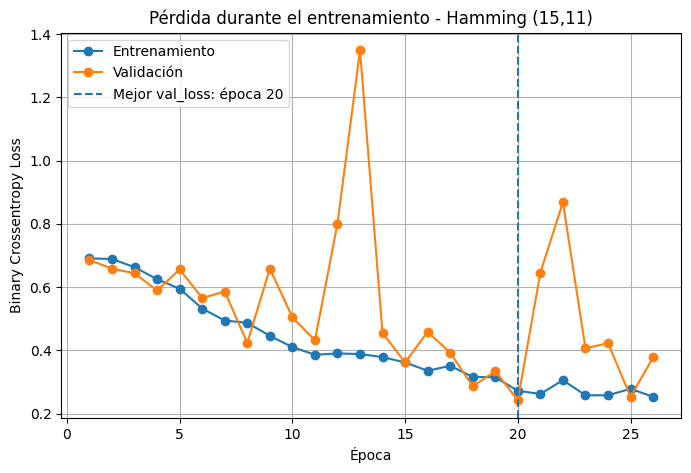

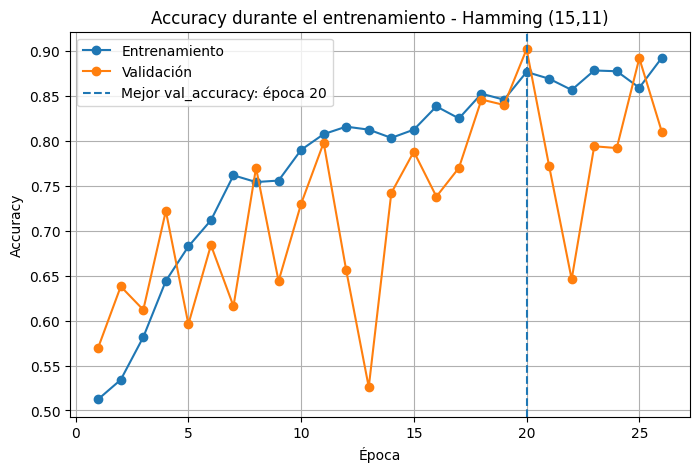

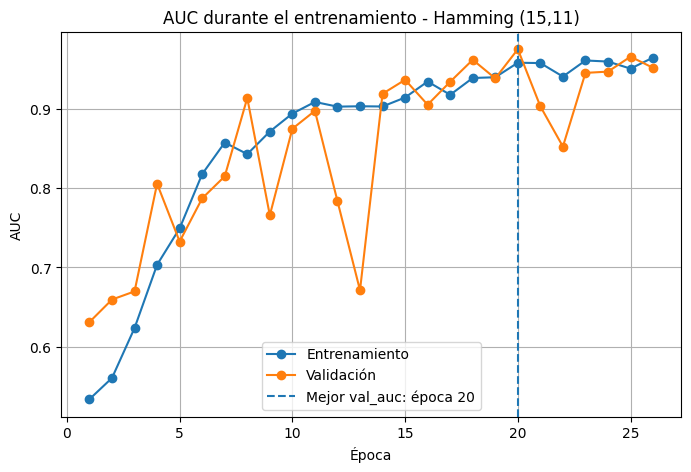

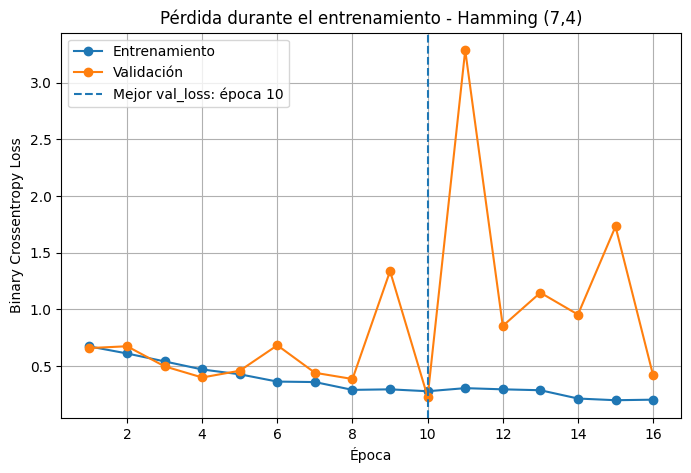

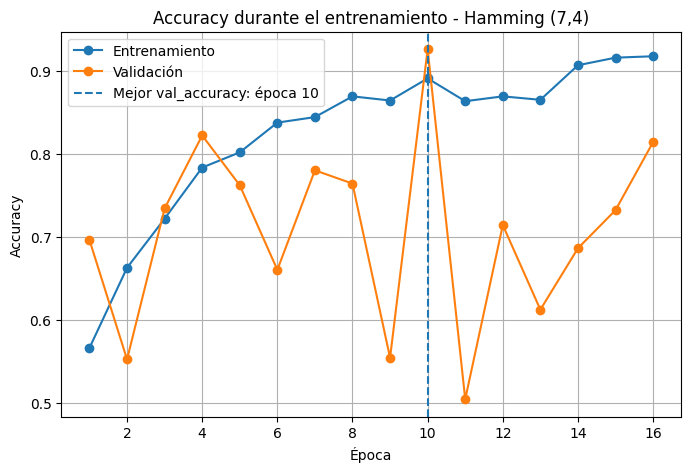

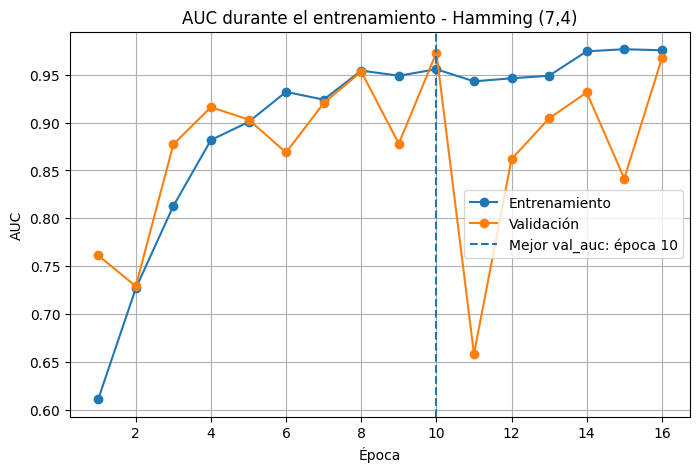

Checkpoint cargado para Hamming (15,11): mejor_modelo_stego_15.pt | época=20 | monitor=0.9752

DIAGNÓSTICO DE SOBREAJUSTE CON MEJOR CHECKPOINT: Hamming (15,11)
Mejor época histórica según val_loss: 20
Mejor val_loss histórico: 0.2423
Último val_loss histórico: 0.3779
Aumento relativo de val_loss respecto al mejor punto: 55.97%

Métricas reales evaluadas con el mismo estado de pesos:
Train loss: 0.2355 | Val loss: 0.2423
Train accuracy: 0.8917 | Val accuracy: 0.9020 | gap=-0.0103
Train AUC: 0.9777 | Val AUC: 0.9752 | gap=0.0025

Interpretación:
No hay señales fuertes de sobreajuste.
El entrenamiento y la validación se comportan de forma relativamente similar.
Checkpoint cargado para Hamming (7,4): mejor_modelo_stego_7.pt | época=10 | monitor=0.9730

DIAGNÓSTICO DE SOBREAJUSTE CON MEJOR CHECKPOINT: Hamming (7,4)
Mejor época histórica según val_loss: 10
Mejor val_loss histórico: 0.2271
Último val_loss histórico: 0.4177
Aumento relativo de val_loss respecto al mejor punto: 83.91%

Métricas

In [25]:
# ============================================================
# DIAGNÓSTICO DE SOBREAJUSTE Y CURVAS DE ENTRENAMIENTO
# ============================================================

def graficar_curvas_entrenamiento(historial, nombre_modelo):
    hist = historial.history
    epocas = range(1, len(hist["loss"]) + 1)

    # ----------------------------
    # Gráfica de pérdida
    # ----------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(epocas, hist["loss"], marker="o", label="Entrenamiento")
    plt.plot(epocas, hist["val_loss"], marker="o", label="Validación")

    mejor_epoca_loss = np.argmin(hist["val_loss"]) + 1

    plt.axvline(
        mejor_epoca_loss,
        linestyle="--",
        label=f"Mejor val_loss: época {mejor_epoca_loss}"
    )

    plt.title(f"Pérdida durante el entrenamiento - {nombre_modelo}")
    plt.xlabel("Época")
    plt.ylabel("Binary Crossentropy Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ----------------------------
    # Gráfica de accuracy
    # ----------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(epocas, hist["accuracy"], marker="o", label="Entrenamiento")
    plt.plot(epocas, hist["val_accuracy"], marker="o", label="Validación")

    mejor_epoca_acc = np.argmax(hist["val_accuracy"]) + 1

    plt.axvline(
        mejor_epoca_acc,
        linestyle="--",
        label=f"Mejor val_accuracy: época {mejor_epoca_acc}"
    )

    plt.title(f"Accuracy durante el entrenamiento - {nombre_modelo}")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ----------------------------
    # Gráfica de AUC, si existe
    # ----------------------------
    if "auc" in hist and "val_auc" in hist:
        plt.figure(figsize=(8, 5))
        plt.plot(epocas, hist["auc"], marker="o", label="Entrenamiento")
        plt.plot(epocas, hist["val_auc"], marker="o", label="Validación")

        mejor_epoca_auc = np.nanargmax(hist["val_auc"]) + 1

        plt.axvline(
            mejor_epoca_auc,
            linestyle="--",
            label=f"Mejor val_auc: época {mejor_epoca_auc}"
        )

        plt.title(f"AUC durante el entrenamiento - {nombre_modelo}")
        plt.xlabel("Época")
        plt.ylabel("AUC")
        plt.legend()
        plt.grid(True)
        plt.show()


def cargar_mejor_checkpoint(modelo, ruta_checkpoint, nombre_modelo):
    if not os.path.exists(ruta_checkpoint):
        print(f"No se encontró checkpoint para {nombre_modelo}: {ruta_checkpoint}")
        return modelo

    # Necesario para checkpoints ya guardados con objetos NumPy dentro del historial.
    # Úsalo solo si el checkpoint fue generado por ti o por una fuente confiable.
    checkpoint = torch.load(
        ruta_checkpoint,
        map_location=device,
        weights_only=False
    )

    modelo.load_state_dict(checkpoint["model_state_dict"])
    modelo.to(device)
    modelo.eval()

    epoca = checkpoint.get("epoca", "desconocida")
    monitor = checkpoint.get("monitor", None)

    if monitor is not None:
        print(f"Checkpoint cargado para {nombre_modelo}: {ruta_checkpoint} | época={epoca} | monitor={monitor:.4f}")
    else:
        print(f"Checkpoint cargado para {nombre_modelo}: {ruta_checkpoint} | época={epoca}")

    return modelo


def evaluar_train_vs_val(modelo, train_ds, val_ds, nombre_modelo, imprimir=True):
    criterio = nn.BCEWithLogitsLoss()

    resultados_train = evaluar_modelo_pytorch(modelo, train_ds, criterio)
    resultados_val = evaluar_modelo_pytorch(modelo, val_ds, criterio)

    if imprimir:
        print("\n" + "="*70)
        print(f"EVALUACIÓN TRAIN VS VALIDATION: {nombre_modelo}")
        print("="*70)

        print("\nResultados en entrenamiento:")
        for metrica, valor in resultados_train.items():
            print(f"{metrica}: {valor:.4f}")

        print("\nResultados en validación:")
        for metrica, valor in resultados_val.items():
            print(f"{metrica}: {valor:.4f}")

        print("\nBrechas train - validation:")
        for metrica in resultados_train.keys():
            brecha = resultados_train[metrica] - resultados_val[metrica]
            print(f"{metrica}: {brecha:.4f}")

    return resultados_train, resultados_val


def diagnosticar_sobreajuste(modelo, train_loader, val_loader, historial, nombre_modelo):
    hist = historial.history
    train_loss_hist = np.array(hist["loss"])
    val_loss_hist = np.array(hist["val_loss"])

    mejor_epoca_val_loss = np.argmin(val_loss_hist)
    mejor_val_loss = val_loss_hist[mejor_epoca_val_loss]
    ultima_val_loss = val_loss_hist[-1]
    aumento_val_loss = (ultima_val_loss - mejor_val_loss) / max(abs(mejor_val_loss), 1e-8)

    resultados_train, resultados_val = evaluar_train_vs_val(
        modelo,
        train_loader,
        val_loader,
        nombre_modelo,
        imprimir=False
    )

    gap_acc = resultados_train["accuracy"] - resultados_val["accuracy"]
    gap_auc = resultados_train["auc"] - resultados_val["auc"]

    print("\n" + "="*70)
    print(f"DIAGNÓSTICO DE SOBREAJUSTE CON MEJOR CHECKPOINT: {nombre_modelo}")
    print("="*70)

    print(f"Mejor época histórica según val_loss: {mejor_epoca_val_loss + 1}")
    print(f"Mejor val_loss histórico: {mejor_val_loss:.4f}")
    print(f"Último val_loss histórico: {ultima_val_loss:.4f}")
    print(f"Aumento relativo de val_loss respecto al mejor punto: {aumento_val_loss*100:.2f}%")

    print("\nMétricas reales evaluadas con el mismo estado de pesos:")
    print(f"Train loss: {resultados_train['loss']:.4f} | Val loss: {resultados_val['loss']:.4f}")
    print(f"Train accuracy: {resultados_train['accuracy']:.4f} | Val accuracy: {resultados_val['accuracy']:.4f} | gap={gap_acc:.4f}")
    print(f"Train AUC: {resultados_train['auc']:.4f} | Val AUC: {resultados_val['auc']:.4f} | gap={gap_auc:.4f}")

    print("\nInterpretación:")

    if aumento_val_loss > 0.10 and (gap_acc > 0.08 or gap_auc > 0.08):
        print("Hay señales claras de SOBREAJUSTE.")
        print("El modelo mejora en entrenamiento, pero pierde generalización en validación.")

    elif gap_acc > 0.10 or gap_auc > 0.10:
        print("Hay posible SOBREAJUSTE.")
        print("La diferencia entre entrenamiento y validación es alta.")

    elif resultados_train['accuracy'] < 0.60 and resultados_val['accuracy'] < 0.60:
        print("No parece sobreajuste fuerte.")
        print("El problema parece más cercano a underfitting, colapso de clase o señal esteganográfica muy débil.")

    else:
        print("No hay señales fuertes de sobreajuste.")
        print("El entrenamiento y la validación se comportan de forma relativamente similar.")


# ============================================================
# EJECUTAR DIAGNÓSTICO PARA AMBOS MODELOS
# ============================================================

graficar_curvas_entrenamiento(
    historial,
    "Hamming (15,11)"
)

graficar_curvas_entrenamiento(
    historial_7,
    "Hamming (7,4)"
)


model_resnet = cargar_mejor_checkpoint(
    model_resnet,
    "mejor_modelo_stego_15.pt",
    "Hamming (15,11)"
)


diagnosticar_sobreajuste(
    model_resnet,
    train_dataset,
    val_dataset,
    historial,
    "Hamming (15,11)"
)

modelo_resnet_7 = cargar_mejor_checkpoint(
    modelo_resnet_7,
    "mejor_modelo_stego_7.pt",
    "Hamming (7,4)"
)


diagnosticar_sobreajuste(
    modelo_resnet_7,
    train_dataset_7,
    val_dataset_7,
    historial_7,
    "Hamming (7,4)"
)


In [26]:
# ============================================================
# EVALUACIÓN FINAL: TRAIN VS VALIDATION EN PYTORCH
# El test se mantiene separado y se evalúa una sola vez en la sección 4.2.
# ============================================================

evaluar_train_vs_val(
    model_resnet,
    train_dataset,
    val_dataset,
    "Hamming (15,11)"
)

evaluar_train_vs_val(
    modelo_resnet_7,
    train_dataset_7,
    val_dataset_7,
    "Hamming (7,4)"
)



EVALUACIÓN TRAIN VS VALIDATION: Hamming (15,11)

Resultados en entrenamiento:
loss: 0.2343
accuracy: 0.9000
auc: 0.9782

Resultados en validación:
loss: 0.2423
accuracy: 0.9020
auc: 0.9752

Brechas train - validation:
loss: -0.0080
accuracy: -0.0020
auc: 0.0030

EVALUACIÓN TRAIN VS VALIDATION: Hamming (7,4)

Resultados en entrenamiento:
loss: 0.1947
accuracy: 0.9283
auc: 0.9819

Resultados en validación:
loss: 0.2271
accuracy: 0.9260
auc: 0.9730

Brechas train - validation:
loss: -0.0324
accuracy: 0.0023
auc: 0.0090


({'loss': 0.19470102230707803,
  'accuracy': np.float64(0.9283333333333333),
  'auc': 0.9819361111111111},
 {'loss': 0.22712956833839418,
  'accuracy': np.float64(0.926),
  'auc': 0.9729840000000001})

# **Fase 4: Evaluación y Discusión**

## 4.1. Evaluación de la red residual: métricas de clasificación

La evaluación final de los modelos se realiza sobre el conjunto de test, el cual se mantuvo completamente separado durante el entrenamiento. Este conjunto no participa en el ajuste de pesos, selección de hiperparámetros, early stopping ni selección de checkpoints.

Para cada modelo se extraen las probabilidades predichas aplicando `sigmoid` sobre los logits producidos por la red. Luego, con un umbral estándar de `0.5`, se convierten esas probabilidades en etiquetas binarias:

```text
0 = cover
1 = stego
```


El desempeño se analiza mediante tres herramientas principales:

1. **Diagnóstico de distribución de predicciones:** permite observar si el modelo está produciendo probabilidades razonablemente distribuidas o si colapsa hacia una sola clase.
2. **Matriz de confusión:** permite identificar aciertos y errores por clase. En este proyecto, los falsos negativos son especialmente importantes, porque corresponden a imágenes stego clasificadas incorrectamente como imágenes limpias. Esta tasa se interpreta como una forma de evasión frente al estegoanalizador.
3. **Curva ROC y AUC:** permiten evaluar la capacidad del modelo para separar imágenes cover y stego sin depender exclusivamente de un único umbral de decisión. Un AUC cercano a `0.5` indica comportamiento similar al azar, mientras que un AUC cercano a `1.0` indica alta capacidad de detección.

Finalmente, se comparan los resultados de Hamming (7,4) y Hamming (15,11). Esta comparación permite discutir si la menor densidad de modificaciones del esquema (15,11) efectivamente dificulta la detección frente al modelo residual entrenado.


In [29]:
print("--- Extrayendo predicciones comparativas de los modelos PyTorch ---")

def obtener_predicciones(modelo, dataloader):
    """Extrae etiquetas reales y probabilidades de un DataLoader de PyTorch."""
    modelo.eval()
    y_real = []
    y_pred_prob = []

    with torch.no_grad():
        for img, label in dataloader:
            img = img.to(device, non_blocking=True)

            with autocast(device_type=AMP_DEVICE_TYPE, enabled=USAR_AMP):
                logits = modelo(img)

            preds = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            labels = label.detach().cpu().numpy().reshape(-1)

            y_real.extend(labels)
            y_pred_prob.extend(preds)

    return np.array(y_real), np.array(y_pred_prob).flatten()


--- Extrayendo predicciones comparativas de los modelos PyTorch ---


In [30]:
# ============================================================
# DIAGNÓSTICO DE COLAPSO DE CLASE
# ============================================================

def diagnosticar_predicciones(nombre, y_real, y_prob):
    y_real = y_real.reshape(-1).astype(int)
    y_prob = y_prob.reshape(-1)

    y_bin = (y_prob > 0.5).astype(int)

    print("\n" + "="*60)
    print(f"DIAGNÓSTICO: {nombre}")
    print("="*60)

    print(f"Clases reales:")
    print(f"  Cover  (0): {np.sum(y_real == 0)}")
    print(f"  Stego  (1): {np.sum(y_real == 1)}")

    print(f"\nPredicciones binarias con umbral 0.5:")
    print(f"  Predicho Cover (0): {np.sum(y_bin == 0)}")
    print(f"  Predicho Stego (1): {np.sum(y_bin == 1)}")

    print(f"\nProbabilidades:")
    print(f"  Media: {y_prob.mean():.4f}")
    print(f"  Mínima: {y_prob.min():.4f}")
    print(f"  Máxima: {y_prob.max():.4f}")
    print(f"  Desviación estándar: {y_prob.std():.4f}")

    if np.all(y_bin == 0):
        print("\nALERTA: el modelo está prediciendo TODO como cover.")
    elif np.all(y_bin == 1):
        print("\nALERTA: el modelo está prediciendo TODO como stego.")
    else:
        print("\nOK: el modelo está usando ambas clases.")

In [31]:
# Evaluación única sobre TEST. No usar estos resultados para ajustar el entrenamiento.
y_real_15, y_prob_15 = obtener_predicciones(model_resnet, test_dataset)
y_real_7, y_prob_7 = obtener_predicciones(modelo_resnet_7, test_dataset_7)

diagnosticar_predicciones("Hamming (15,11) - TEST", y_real_15, y_prob_15)
diagnosticar_predicciones("Hamming (7,4) - TEST", y_real_7, y_prob_7)



DIAGNÓSTICO: Hamming (15,11) - TEST
Clases reales:
  Cover  (0): 150
  Stego  (1): 150

Predicciones binarias con umbral 0.5:
  Predicho Cover (0): 132
  Predicho Stego (1): 168

Probabilidades:
  Media: 0.5073
  Mínima: 0.0000
  Máxima: 0.9985
  Desviación estándar: 0.3948

OK: el modelo está usando ambas clases.

DIAGNÓSTICO: Hamming (7,4) - TEST
Clases reales:
  Cover  (0): 150
  Stego  (1): 150

Predicciones binarias con umbral 0.5:
  Predicho Cover (0): 155
  Predicho Stego (1): 145

Probabilidades:
  Media: 0.4731
  Mínima: 0.0000
  Máxima: 1.0000
  Desviación estándar: 0.4058

OK: el modelo está usando ambas clases.


In [32]:
# 1. Usar las predicciones de TEST obtenidas en la celda anterior.
# No se vuelve a llamar obtener_predicciones para evitar evaluar el test más de una vez.
if "y_real_15" not in globals() or "y_prob_15" not in globals() or "y_real_7" not in globals() or "y_prob_7" not in globals():
    raise RuntimeError("Ejecuta primero la celda anterior para obtener las predicciones de test.")

# 2. Binarización mediante umbral estándar (0.5)
y_bin_15 = (y_prob_15 > 0.5).astype(int)
y_bin_7 = (y_prob_7 > 0.5).astype(int)

cm_15 = confusion_matrix(y_real_15, y_bin_15)
cm_7 = confusion_matrix(y_real_7, y_bin_7)

# 3. Cálculo de coordenadas para las Curvas ROC y AUC
fpr_15, tpr_15, _ = roc_curve(y_real_15, y_prob_15)
auc_15 = auc(fpr_15, tpr_15)

fpr_7, tpr_7, _ = roc_curve(y_real_7, y_prob_7)
auc_7 = auc(fpr_7, tpr_7)


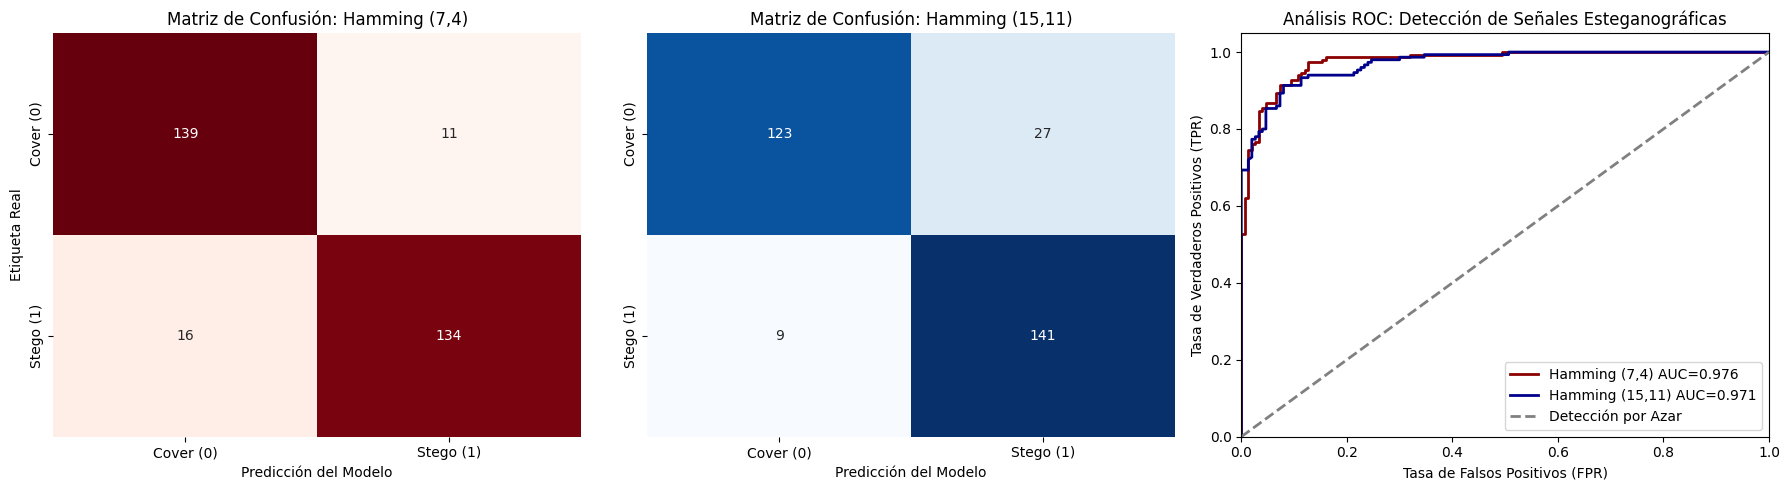

In [33]:
# --- 5. DIAGRAMACIÓN VISUAL UNIFICADA ---
plt.figure(figsize=(18, 5))

# Subplot 1: Matriz de Confusión 7,4 (Tonos Rojos para diferenciar)
plt.subplot(1, 3, 1)
sns.heatmap(cm_7, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Cover (0)', 'Stego (1)'],
            yticklabels=['Cover (0)', 'Stego (1)'])
plt.title('Matriz de Confusión: Hamming (7,4)')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')

# Subplot 2: Matriz de Confusión 15,11 (Tonos Azules)
plt.subplot(1, 3, 2)
sns.heatmap(cm_15, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Cover (0)', 'Stego (1)'],
            yticklabels=['Cover (0)', 'Stego (1)'])
plt.title('Matriz de Confusión: Hamming (15,11)')
plt.xlabel('Predicción del Modelo')

# Subplot 3: Curvas ROC Superpuestas
plt.subplot(1, 3, 3)
plt.plot(fpr_7, tpr_7, color='darkred', lw=2, label=f'Hamming (7,4) AUC={auc_7:.3f}')
plt.plot(fpr_15, tpr_15, color='darkblue', lw=2, label=f'Hamming (15,11) AUC={auc_15:.3f}')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Detección por Azar')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Análisis ROC: Detección de Señales Esteganográficas')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

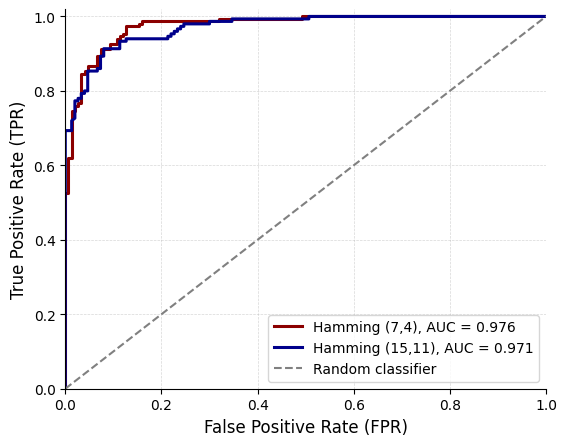

In [36]:
# Create output folder if it does not exist
os.makedirs("figures", exist_ok=True)

# General figure configuration
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

fig, ax = plt.subplots(figsize=(5.8, 4.6))

# ROC curves
ax.plot(
    fpr_7, tpr_7,
    linewidth=2.2,
    label=f"Hamming (7,4), AUC = {auc_7:.3f}",
    color='darkred'
)

ax.plot(
    fpr_15, tpr_15,
    linewidth=2.2,
    linestyle="-",
    label=f"Hamming (15,11), AUC = {auc_15:.3f}",
    color='darkblue'
)

# Random classifier baseline
ax.plot(
    [0, 1], [0, 1],
    linestyle="--",
    linewidth=1.5,
    color="gray",
    label="Random classifier"
)

# Axis formatting
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.02)

ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")

ax.set_xticks(np.linspace(0, 1, 6))
ax.set_yticks(np.linspace(0, 1, 6))

# Subtle grid
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# Legend
ax.legend(loc="lower right", frameon=True)

# Remove unnecessary borders for a cleaner academic style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Layout and export
plt.tight_layout()

plt.savefig(
    "figures/roc_comparison.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [35]:
# --- 6. Análisis Estadístico de Evasión ---
fn_7 = cm_7[1, 0]
total_7 = np.sum(cm_7[1, :])
tasa_evasion_7 = (fn_7 / total_7) * 100 if total_7 > 0 else 0

fn_15 = cm_15[1, 0]
total_15 = np.sum(cm_15[1, :])
tasa_evasion_15 = (fn_15 / total_15) * 100 if total_15 > 0 else 0

print("\n" + "="*50)
print("RESUMEN ESTADÍSTICO DE EVASIÓN ESTEGANOGRÁFICA")
print("="*50)
print(f"Esquema (7,4)   - Falsos Negativos: {fn_7}/{total_7} -> Tasa de Evasión: {tasa_evasion_7:.2f}%")
print(f"Esquema (15,11) - Falsos Negativos: {fn_15}/{total_15} -> Tasa de Evasión: {tasa_evasion_15:.2f}%")
print("-" * 50)

if tasa_evasion_15 > tasa_evasion_7:
    print("CONCLUSIÓN: Hipótesis confirmada. El esquema (15,11) es criptográficamente")
    print("más robusto y presenta mayor dificultad de detección forense.")
else:
    print("CONCLUSIÓN: El factor de regularización de la red mitigó el ruido en ambos")
    print("esquemas, logrando tasas de detección similares.")


RESUMEN ESTADÍSTICO DE EVASIÓN ESTEGANOGRÁFICA
Esquema (7,4)   - Falsos Negativos: 16/150 -> Tasa de Evasión: 10.67%
Esquema (15,11) - Falsos Negativos: 9/150 -> Tasa de Evasión: 6.00%
--------------------------------------------------
CONCLUSIÓN: El factor de regularización de la red mitigó el ruido en ambos
esquemas, logrando tasas de detección similares.
